In [1]:
!pip install -q sentence-transformers matplotlib seaborn

from sentence_transformers import SentenceTransformer, util
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# 10 sentences across Cricket, Cooking, Cybersecurity
sentences = [
    # Cricket
    "The batsman scored a century in the final match.",
    "The cricket team celebrated their victory with fans.",
    "The bowler delivered a perfect yorker to dismiss the batsman.",
    "Fielding errors cost the team crucial runs.",

    # Cooking
    "The chef prepared a delicious pasta with fresh herbs.",
    "Baking bread requires patience and precise measurements.",
    "The recipe calls for garlic, onions, and tomatoes.",

    # Cybersecurity
    "Strong passwords help protect accounts from hackers.",
    "Phishing emails often trick users into revealing personal data.",
    "Encryption ensures that sensitive information remains secure."
]


In [ ]:
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences, convert_to_tensor=True)

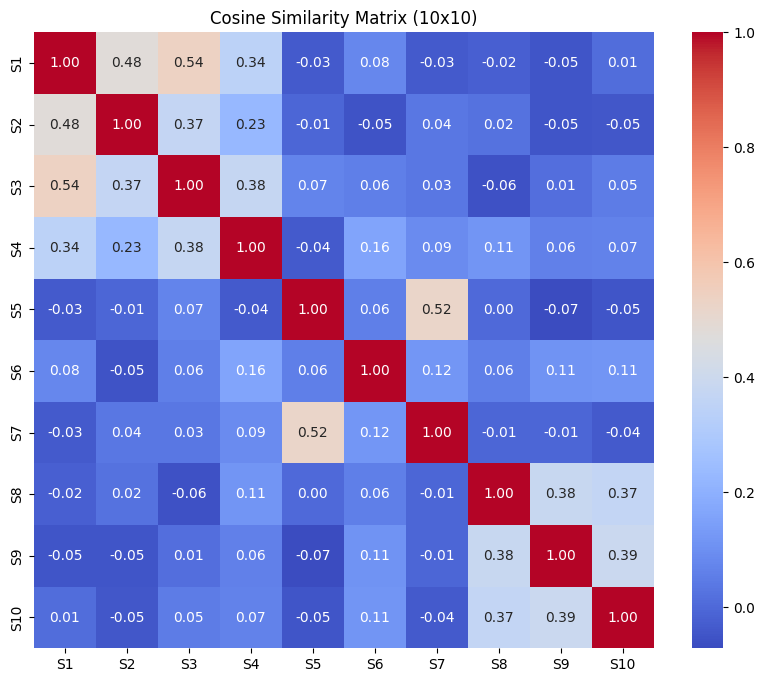

In [4]:
cosine_sim_matrix = util.cos_sim(embeddings, embeddings).cpu().numpy()

plt.figure(figsize=(10,8))
sns.heatmap(cosine_sim_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            xticklabels=[f"S{i+1}" for i in range(len(sentences))],
            yticklabels=[f"S{i+1}" for i in range(len(sentences))])
plt.title("Cosine Similarity Matrix (10x10)")
plt.show()


In [5]:
query = "The bowler took three wickets in one over"
query_embedding = model.encode(query, convert_to_tensor=True)

similarities = util.cos_sim(query_embedding, embeddings).cpu().numpy()[0]
top_indices = similarities.argsort()[-2:][::-1]

print("Query:", query)
print("\nTop 2 most similar sentences:")
for idx in top_indices:
    print(f"Sentence: {sentences[idx]} | Similarity: {similarities[idx]:.4f}")


Query: The bowler took three wickets in one over

Top 2 most similar sentences:
Sentence: The bowler delivered a perfect yorker to dismiss the batsman. | Similarity: 0.5954
Sentence: The batsman scored a century in the final match. | Similarity: 0.5679
